<a href="https://colab.research.google.com/github/tasosquantumcomputing/Machine-Learning/blob/main/Bank_Marketing_Prediction_using_Decision_Tree_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Marketing Prediction using Decision Tree Classifier

## Project Objective

The objective of this project is to build a Decision Tree Classifier
that predicts whether a bank customer will subscribe to a term deposit
after a marketing campaign.

The project focuses on:

- Exploratory Data Analysis
- Data preprocessing
- Categorical feature encoding
- Preventing data leakage
- Training a Decision Tree Classifier
- Evaluating classification performance
- Controlling overfitting
- Hyperparameter tuning and pruning
- Feature importance and model interpretation

The dataset is obtained from the UCI Machine Learning Repository.

In [2]:
!pip install -q ucimlrepo

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from ucimlrepo import fetch_ucirepo

bank_marketing = fetch_ucirepo(id=222)

In [5]:
X = bank_marketing.data.features
y = bank_marketing.data.targets

In [6]:
print(X.shape)
print(y.shape)

(45211, 16)
(45211, 1)


In [7]:
df = X.copy()
df["deposit"] = y.iloc[:, 0]

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,deposit
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 45211
Number of columns: 17


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  deposit      45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
df.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [11]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,44923,45211,43354,45211,45211,45211,32191,45211,8252,45211
unique,11,3,3,2,2,2,2,12,3,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,failure,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,4901,39922


In [12]:
df["deposit"].value_counts()

,count
deposit,
no,39922
yes,5289


In [13]:
df["deposit"].value_counts(normalize=True)

,proportion
deposit,
no,0.883015
yes,0.116985


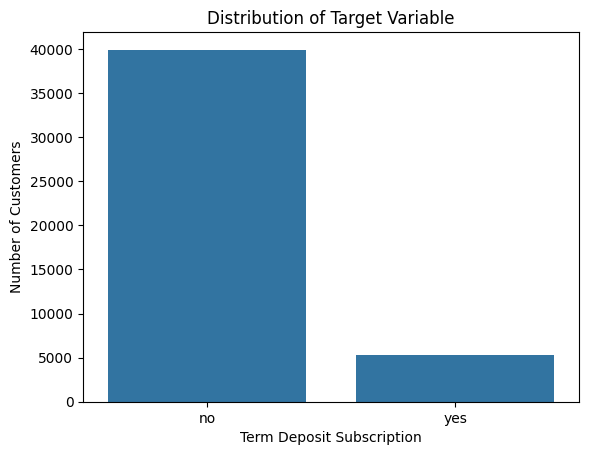

In [14]:
sns.countplot(data=df, x="deposit")

plt.title("Distribution of Target Variable")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Customers")
plt.show()

Check missing values

In [15]:
df.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


In [16]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 52124


In [17]:
df.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


In [18]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 52124


In [19]:
df["duration"].describe()

,duration
count,45211.000000
mean,258.163080
std,257.527812
min,0.000000
25%,103.000000
50%,180.000000
75%,319.000000
max,4918.000000


In [20]:
df = df.drop(columns="duration")

### Removing the `duration` Feature to Prevent Data Leakage

The `duration` feature represents the duration of the last contact with the customer.

Although this variable is strongly related to whether a customer subscribes to a term deposit, it should not be used in a realistic prediction model. The reason is that the duration of a call is only known **after the call has already taken place**.

In a real-world scenario, the bank would want to predict which customers are most likely to subscribe **before contacting them**. At that point, the call duration is not yet available.

Using this feature would therefore introduce **data leakage**, because the model would receive information that would not be available at the moment when the prediction is actually needed.

Data leakage can lead to unrealistically high model performance during training and evaluation, but poor performance when the model is deployed in a real environment.

For this reason, the `duration` feature is removed from the dataset before training the classifier.

```python
df = df.drop(columns="duration")
```

This makes the evaluation more realistic and ensures that the model only uses information that would actually be available before the marketing call.


## Exploratory Data Analysis

Before training the Decision Tree, we first examine the structure of the dataset
and investigate how different features are related to the target variable.

The goal of EDA is not only to visualize the data, but also to identify patterns,
potential problems, class imbalance, unusual values, and features that may be useful
for prediction.

In [21]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

categorical_features = [
    col for col in df.select_dtypes(include="object").columns
    if col != "deposit"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [22]:
target_counts = df["deposit"].value_counts()
target_percentages = df["deposit"].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_percentages)

deposit
no     39922
yes     5289
Name: count, dtype: int64

deposit
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


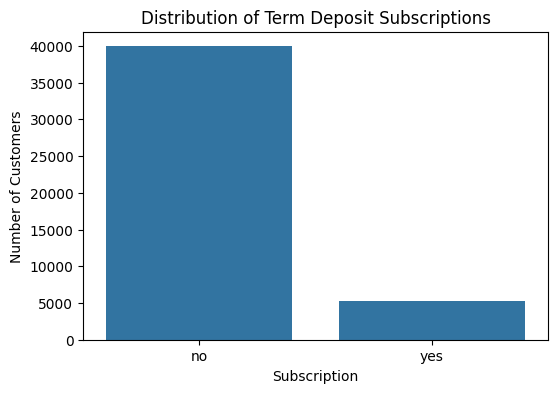

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="deposit"
)

plt.title("Distribution of Term Deposit Subscriptions")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

### Class Imbalance

The target variable is imbalanced, with significantly more customers who did not
subscribe to a term deposit than customers who did.

Because of this imbalance, accuracy alone may not provide a complete picture of
model performance.

For example, a classifier that predicts "no" for most customers may achieve a
relatively high accuracy while performing poorly at identifying potential subscribers.

Therefore, additional metrics such as precision, recall, F1-score, and ROC-AUC
will also be considered.

In [24]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day_of_week,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


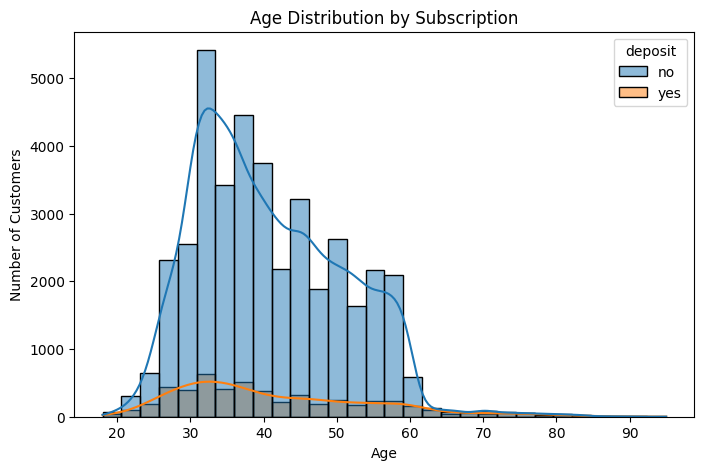

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="deposit",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Subscription")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

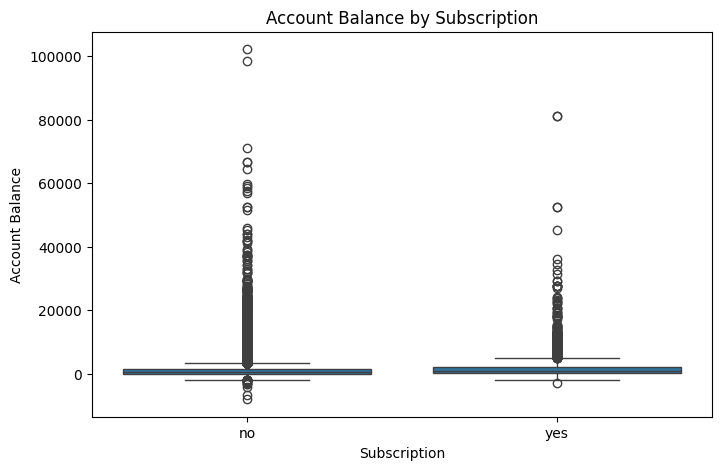

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="deposit",
    y="balance"
)

plt.title("Account Balance by Subscription")
plt.xlabel("Subscription")
plt.ylabel("Account Balance")

plt.show()

In [27]:
job_subscription = (
    df.groupby("job")["deposit"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
)

job_subscription

,deposit
job,
student,0.286780
retired,0.227915
unemployed,0.155027
management,0.137556
admin.,0.122027
self-employed,0.118429
technician,0.110570
services,0.088830
housemaid,0.087903


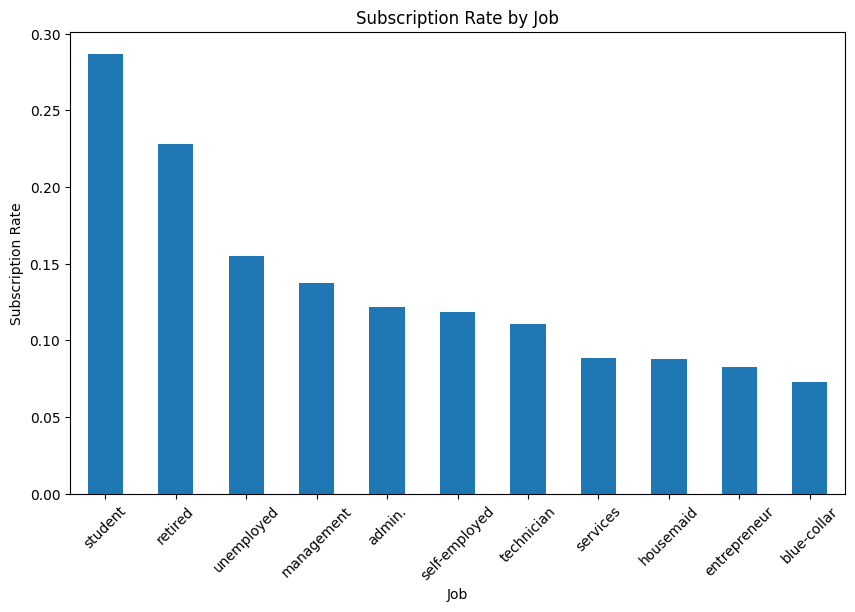

In [28]:
plt.figure(figsize=(10, 6))

job_subscription.plot(kind="bar")

plt.title("Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)

plt.show()

In [29]:
education_subscription = (
    df.groupby("education")["deposit"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
)

education_subscription

,deposit
education,
tertiary,0.150064
secondary,0.105594
primary,0.086265


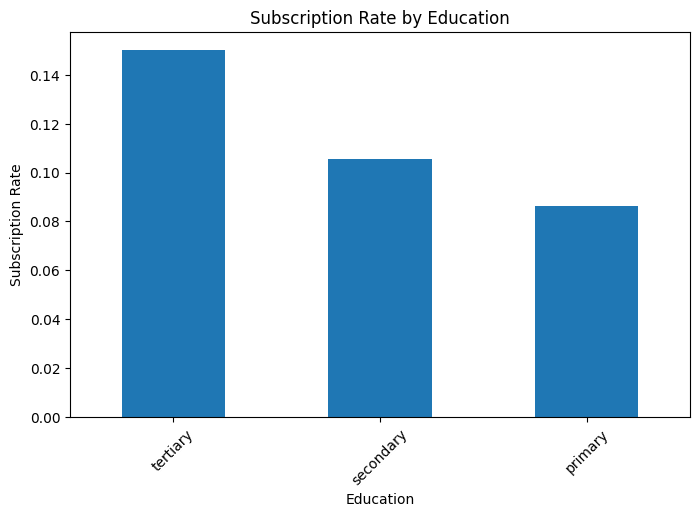

In [30]:
plt.figure(figsize=(8, 5))

education_subscription.plot(kind="bar")

plt.title("Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)

plt.show()

In [31]:
poutcome_subscription = (
    df.groupby("poutcome")["deposit"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
)

poutcome_subscription

,deposit
poutcome,
success,0.647253
other,0.166848
failure,0.126097


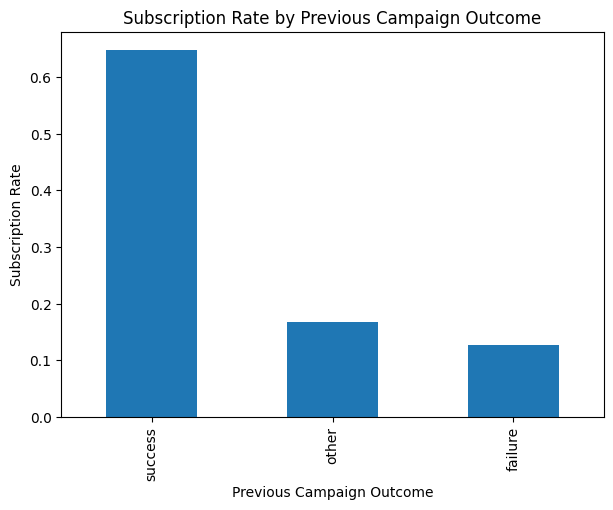

In [32]:
plt.figure(figsize=(7, 5))

poutcome_subscription.plot(kind="bar")

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate")

plt.show()

Check for unknown categories

In [33]:
for column in categorical_features:

    unknown_count = (df[column] == "unknown").sum()

    if unknown_count > 0:
        print(f"{column}: {unknown_count} unknown values")

### Handling "Unknown" Categories

Some categorical features contain the value `"unknown"`.

These values are not technically missing values (`NaN`). Instead, `"unknown"`
represents a category where the information was not available.

For this project, these values will be retained as a separate category rather than
removed or imputed. A Decision Tree may determine whether the presence of an unknown
value contains useful predictive information.

In [34]:
X = df.drop(columns="deposit")

y = df["deposit"].map({
    "no": 0,
    "yes": 1
})

In [35]:
print(X.shape)
print(y.shape)

print()
print(y.value_counts())

(45211, 15)
(45211,)

deposit
0    39922
1     5289
Name: count, dtype: int64


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

επειδη θέλουμε την ίδια ανολογία yes no train/test split

In [38]:
print("Training set:")
print(X_train.shape)

print("\nTest set:")
print(X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set:
(36168, 15)

Test set:
(9043, 15)

Training target distribution:
deposit
0    0.883018
1    0.116982
Name: proportion, dtype: float64

Test target distribution:
deposit
0    0.883003
1    0.116997
Name: proportion, dtype: float64


### Why Split the Data Before Preprocessing?

The dataset is divided into training and test sets before fitting any preprocessing
transformations.

This is important because preprocessing should learn information only from the
training data.

If preprocessing is fitted using the entire dataset, information from the test set
may indirectly influence the model, leading to data leakage and an overly optimistic
estimate of model performance.

The test set should remain unseen until the final evaluation.

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

### Why Feature Scaling Is Not Required

Decision Trees do not require feature scaling.

Unlike algorithms such as K-Nearest Neighbors or Support Vector Machines, Decision
Trees do not rely on distances between observations.

Instead, they create decision rules based on feature thresholds.

For example:

`age <= 35`

or

`balance <= 1500`

Therefore, differences in the numerical scales of the features do not directly
affect the tree-building process.

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [42]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [43]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", decision_tree)
    ]
)

In [44]:
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [45]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 1.0
Test Accuracy: 0.8329094327103838


## Baseline Decision Tree

The first model is an unrestricted Decision Tree Classifier using the default
Gini impurity criterion.

No constraints are initially placed on the depth or complexity of the tree.

This baseline model allows us to observe one of the main weaknesses of Decision
Trees: their tendency to overfit the training data.

If the training accuracy is significantly higher than the test accuracy, the tree
has likely learned patterns that are specific to the training set rather than
general patterns that transfer well to unseen customers.

In [46]:
y_pred = model.predict(X_test)

In [48]:
y_prob = model.predict_proba(X_test)[:, 1]

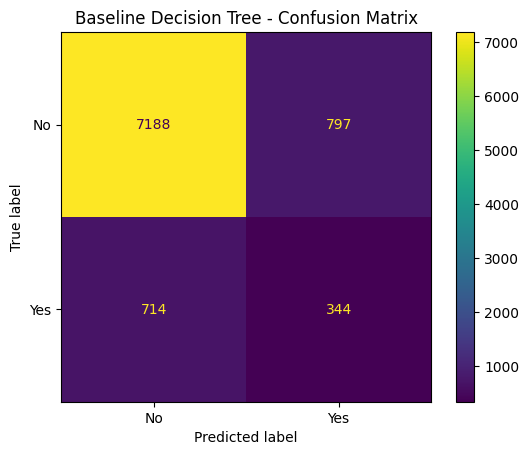

In [49]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
).plot()

plt.title("Baseline Decision Tree - Confusion Matrix")
plt.show()

### Confusion Matrix

The confusion matrix provides a more detailed view of model performance than
accuracy alone.

In this project:

- **True Negative (TN):** The customer did not subscribe and the model correctly
  predicted "No".
- **False Positive (FP):** The model predicted that the customer would subscribe,
  but the customer actually did not.
- **False Negative (FN):** The customer subscribed, but the model predicted "No".
- **True Positive (TP):** The customer subscribed and the model correctly
  predicted "Yes".

False positives may lead to unnecessary marketing contacts, while false negatives
represent potential subscribers that the bank may fail to identify.

In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No", "Yes"]
    )
)

              precision    recall  f1-score   support

          No       0.91      0.90      0.90      7985
         Yes       0.30      0.33      0.31      1058

    accuracy                           0.83      9043
   macro avg       0.61      0.61      0.61      9043
weighted avg       0.84      0.83      0.84      9043



In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred)
baseline_recall = recall_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)
baseline_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)
print("ROC-AUC:", baseline_auc)

Accuracy: 0.8329094327103838
Precision: 0.30148992112182293
Recall: 0.32514177693761814
F1-score: 0.3128694861300591
ROC-AUC: 0.6126648145802681


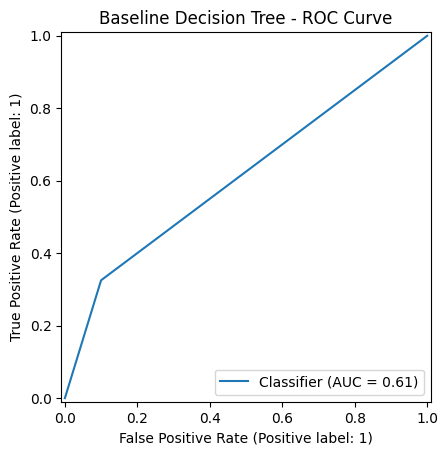

In [53]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Baseline Decision Tree - ROC Curve")
plt.show()

In [54]:
baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Baseline Decision Tree": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_auc
    ]
})

baseline_results

,Metric,Baseline Decision Tree
0,Accuracy,0.832909
1,Precision,0.301490
2,Recall,0.325142
3,F1-score,0.312869
4,ROC-AUC,0.612665


In [55]:
tree_model = model.named_steps["classifier"]

print("Tree depth:", tree_model.get_depth())
print("Number of leaves:", tree_model.get_n_leaves())
print("Number of nodes:", tree_model.tree_.node_count)

Tree depth: 47
Number of leaves: 4769
Number of nodes: 9537


In [56]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Difference: {train_accuracy - test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.8329
Difference: 0.1671
